# Testing the Random Walk in Python

- In this notebook we will apply the methodology of the R notebook 'Testing the random walk in R' but in Python and with antother stock (TSMC)

- The objective is to learn how was the methodology of Lo & Mackinely to check if stocks can be modeled/explain with a random walk model

- THe orignal material is from the MITx Course math for quant finance


In [3]:
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

## 1. Download the data

- We are chosing TSMC stock historical data, from my perspective is a really interesting company to analyze due to its strategic role in the current AI era.
- We are going to analyze data from 2000 to 2025 importing it from Yahoo Finance 

In [6]:
ticker = "TSM"
start_date = "1999-12-31"
end_date = "2025-12-31"

tsm = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    interval="1d",
    auto_adjust=False,  # if true yahoo automtically modifies the open/close/low prices using adjustemnt factors
)
tsm.head()

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,TSM,TSM,TSM,TSM,TSM,TSM
Date,,,,,,
1999-12-31,8.424753,17.059277,17.154051,16.798651,16.846037,428125
2000-01-03,8.869396,17.959627,18.007015,17.462067,17.912241,2062807
2000-01-04,8.927901,18.078094,18.670431,17.912241,17.959627,2557142
2000-01-05,8.986409,18.196564,18.362417,18.078094,18.243950,2295467
2000-01-06,8.611974,17.438372,17.793774,17.059277,17.770081,1539456


<Figure size 1000x500 with 0 Axes>

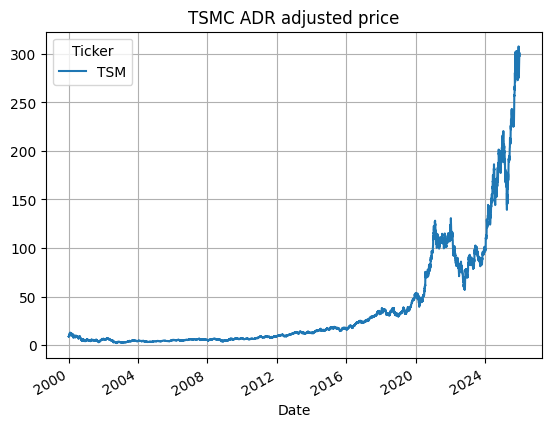

In [13]:
adj_prices = tsm["Adj Close"].dropna()
# this is how prices look over time, we can obersrve the AI boom int he last years
plt.figure(figsize=(10, 5))
adj_prices.plot(title="TSMC ADR adjusted price")
plt.grid()
plt.show()

- Adj price plots helps us to understand growth, global bubbles, compouding and trends,
- But return plots tells how uncertainity behaves through time!

## 2. Computing the log returns (P_t/P_t-1)

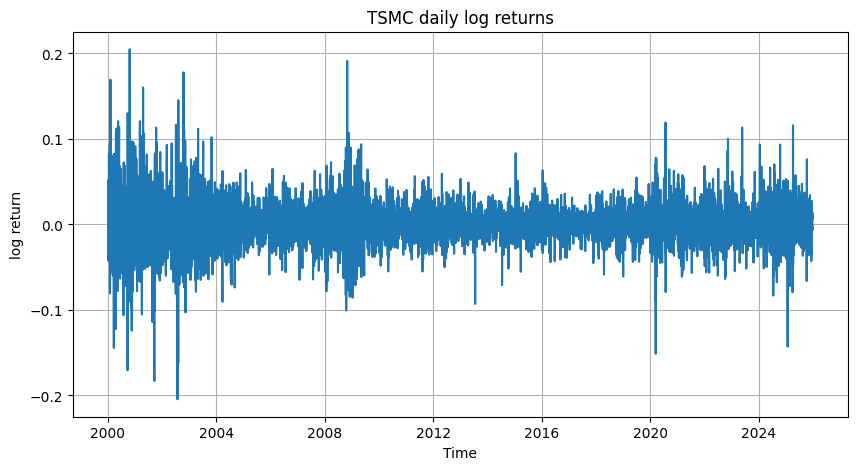

In [14]:
tsm["r"] = np.log(tsm["Adj Close"] / tsm["Adj Close"].shift(1))
tsm = tsm.dropna()
N = len(tsm["r"])

plt.figure(figsize=(10, 5))
plt.plot(tsm.index, tsm["r"])
plt.title("TSMC daily log returns")
plt.xlabel("Time")
plt.ylabel("log return")

plt.grid()
plt.show()

- It is interesting how the adj prices has increase over time but when we look at the log returns, the behavior is really noisy!

- Regarding to the random walk test, we can observe how the mean is barely visible, the scale of of the noise fluctuations is not constant over time.

- This is the phenomenom of time varying volatility!

## 3. Compare the behavior with a simulation using the same metrics

- We want to know: what would this process look like if it were generated using a random walk model?

Volatility of the TSM log returns: 0.025800353945380675


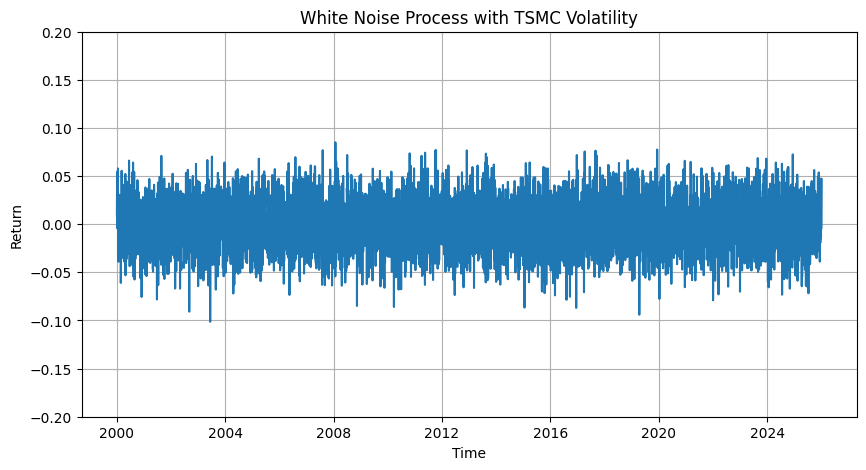

In [17]:
noise = np.random.normal(
    loc=0, scale=tsm["r"].std(), size=len(tsm["r"])
)  # we want to simulate the returns scaling them with the sd of TSM

print(f"Volatility of the TSM log returns: {tsm['r'].std()}")

plt.figure(figsize=(10, 5))
plt.plot(tsm.index, noise)
plt.ylim(-0.20, 0.20)
plt.title("White Noise Process with TSMC Volatility")
plt.xlabel("Time")
plt.ylabel("Return")
plt.grid()
plt.show()

- We are simulating a set of random variables drawn from a normal distribution scaled to have 0 mean and and 0.025 std as TSM does

- They don't exactly look the same, the simulated process looks is much uniform over time, there are not those spikes, clusters of volatility

- So this suggest that volatility itself may vary over time! and when we talk about volatility of a process maybe that is something that we would like to generalize.

## 4. Summary statistics and return distribution

In [19]:
tsm.describe()

Price,Adj Close,Close,High,Low,Open,Volume,r
Ticker,TSM,TSM,TSM,TSM,TSM,TSM,
count,6538.000000,6538.000000,6538.000000,6538.000000,6538.000000,6.538000e+03,6538.000000
mean,37.389362,42.484634,43.003545,41.964686,42.506690,1.064377e+07,0.000545
std,55.192269,55.219049,55.943198,54.496547,55.272962,6.208318e+06,0.025800
min,1.974373,3.997906,4.162306,3.968015,3.997906,7.544770e+05,-0.204468
25%,5.513084,9.960199,10.122640,9.810945,9.970037,6.519725e+06,-0.012073
50%,11.973332,17.530001,17.705000,17.350000,17.535001,9.313300e+06,0.000427
75%,37.295018,44.057501,44.397501,43.580002,44.015000,1.308858e+07,0.012779
max,307.715302,310.140015,313.980011,302.500000,310.929993,6.866750e+07,0.204928


## 5. Annualization conventions

We typically report return and risk measures in annualized terms. It is a convention to use these rules in order to annualize (scale) our metrics:

- Annualized return = 252 * (Daily return)
- Annualized std. dev. = sqrt(252) * (Daily std. dev)
- For monthly returns, replace the 252 by 12.



In [22]:
tsm["r"].mean() * 252  # Mean return for TR (annualize by 252 days/year)

np.float64(0.13744962926479024)

In [26]:
tsm["r"].std() * np.sqrt(
    252
)  # Volatility of TR (annualize with square root due to the random walk model!)

np.float64(0.40956792166152844)

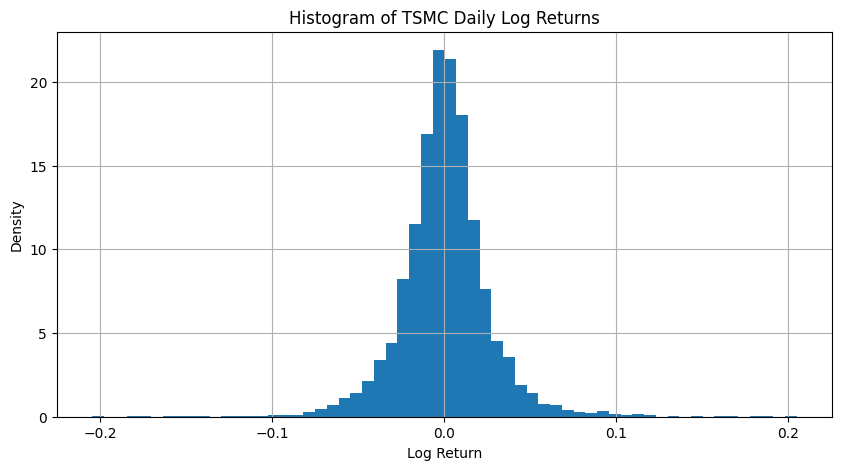

In [31]:
plt.figure(figsize=(10, 5))

plt.hist(tsm["r"], bins=60, density=True)

plt.title("Histogram of TSMC Daily Log Returns")
plt.xlabel("Log Return")
plt.ylabel("Density")

plt.grid()

plt.show()

- The histogram look a little bit gaussian, gathered in the center, like a bell curve but squished in the middle

- When we are interested in the sum of the random variables, whether the individual random variables are drawn from a normal distribution, or whether by binomial distribution, does not make any difference in terms of a large scale properties when we add a large number of r.v. (central limit theorem)

- But we can see fat tails, more extreme values, and relatively fewer medium returns... but this tells us nothing about causality related to time! (predictability, random walks, etc)

## 6. Lo & MacKinlay

Following Lo & MacKinlay, we ask whether the measured sample variance of returns grows linearly as function of the observation interval.

In [37]:
a = np.array([1, 2, 3])
a[::2]

array([1, 3])

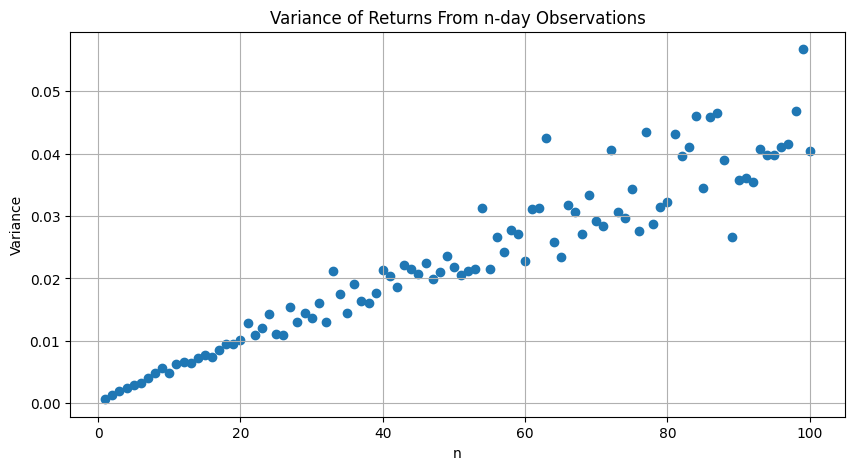

In [42]:
variance = []

P = tsm["Adj Close"].squeeze()

daily_returns = np.diff(np.log(P))

variance.append(np.var(daily_returns))

# aggregated horizons
for n in range(2, 101):

    sampled_prices = P.iloc[
        ::n
    ]  # we are chaing the samples, like prices of 1 day , 2 days, 3 days...

    sampled_returns = np.diff(np.log(sampled_prices))

    variance.append(np.var(sampled_returns))

plt.figure(figsize=(10, 5))

plt.scatter(range(1, 101), variance)

plt.xlabel("n")
plt.ylabel("Variance")
plt.title("Variance of Returns From n-day Observations")
plt.grid()
plt.show()

- Lo and Mackinley instead of letting the time grows and just adding more and more days to calcualte the variance (letting effects of market conditions), they ask about taking a fixed number of of days, and looking different course screening, 

- So we can look at daily observations, then we can group them in two day observations, then 4 and so on

- Then we take the variance of the log retuns computed with different granularities (from 1 to 100)

- We can see that there is a generally linear behavior, variance may grows linear with time,

- But in the recent periods we can observe how the scatter gets worse, suggesting a breakdown of the random walk hypothesis as our observation windows get larget

- But it may also be due because as we group our oversatinos with more periods, less observations do we have and less statistical significance

## 7. Variance Ratios

Here we define functions for 𝜎ˆ2𝑐
, which is a function of a series of observations 𝑋𝑡
 and an aggregation length 𝑞
.

The 𝑧
-statistics and 𝑝
-values follow from the distribution of the estimator as a random variable

In [ ]:
from scipy.stats import norm

# adjusted prices
P = tsm["Adj Close"].squeeze().dropna()
# log prices
X = np.log(P)

T = len(X) - 1

# we estimate average drift
mu_1 = (X.iloc[-1] - X.iloc[0]) / T
# 1-period log returns
returns_1 = []

for t in range(1, T + 1):
    r1 = X.iloc[t] - X.iloc[t - 1]
    returns_1.append(r1)

# we remove drift
adjusted_returns_1 = np.array(returns_1) - mu_1
# we calculate the square deviations deviations
sumsq_1 = np.sum(adjusted_returns_1**2)
# finite sample correction
m_1 = (T - 1) * (T - 1 + 1) * 1 / T

# variance estimate for q = 1
variance_1 = sumsq_1 / m_1


variance_ratios = []
zstats = []
pvalues = []

# horizons from 2 to 100
qs = range(2, 101)

for q in qs:
    mu = (X.iloc[-1] - X.iloc[0]) / T
    q_returns = []
    for t in range(q, T + 1):
        rq = X.iloc[t] - X.iloc[t - q]
        q_returns.append(rq)

    adjusted_returns = np.array(q_returns) - q * mu
    sumsq = np.sum(adjusted_returns**2)
    m = (T - q) * (T - q + 1) * q / T

    variance_q = sumsq / m
    VR = variance_q / variance_1
    variance_ratios.append(VR)

    c = np.sqrt(T * (3 * q) / (2 * (2 * q - 1) * (q - 1)))

    z = c * (VR - 1)
    zstats.append(z)
    p = 2 * norm.cdf(-abs(z))
    pvalues.append(p)

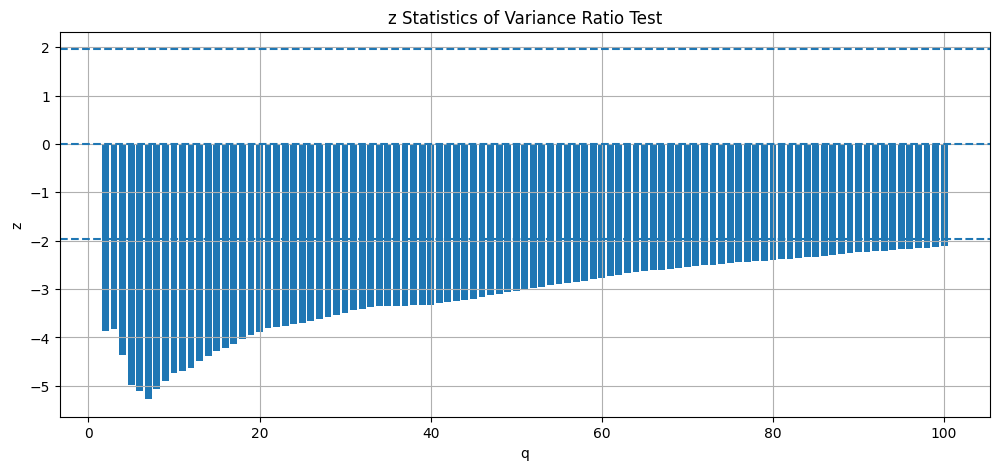

In [48]:
plt.figure(figsize=(12, 5))

plt.bar(qs, zstats)

plt.axhline(0, linestyle="--")
plt.axhline(1.96, linestyle="--")
plt.axhline(-1.96, linestyle="--")

plt.xlabel("q")
plt.ylabel("z")
plt.title("z Statistics of Variance Ratio Test")

plt.grid()
plt.show()

- Since most of the z-statistics are below the -1.96 threshold, we reject the random walk hypothesis for many observation windows of TSMC returns.

- This suggests that TSMC returns do not behave as a pure IID random walk process and may contain some temporal dependence or mean-reverting behavior.

- Interestingly, as the aggregation window q increases, the z-statistics gradually move closer to 0.

- This may indicate that short-run deviations from the random walk are stronger, while at longer horizons the process behaves more similarly to an independent random walk.

- One possible explanation is that short-term market noise, microstructure effects, or temporary reversals have a stronger impact at small horizons and become weaker as returns are aggregated through time.

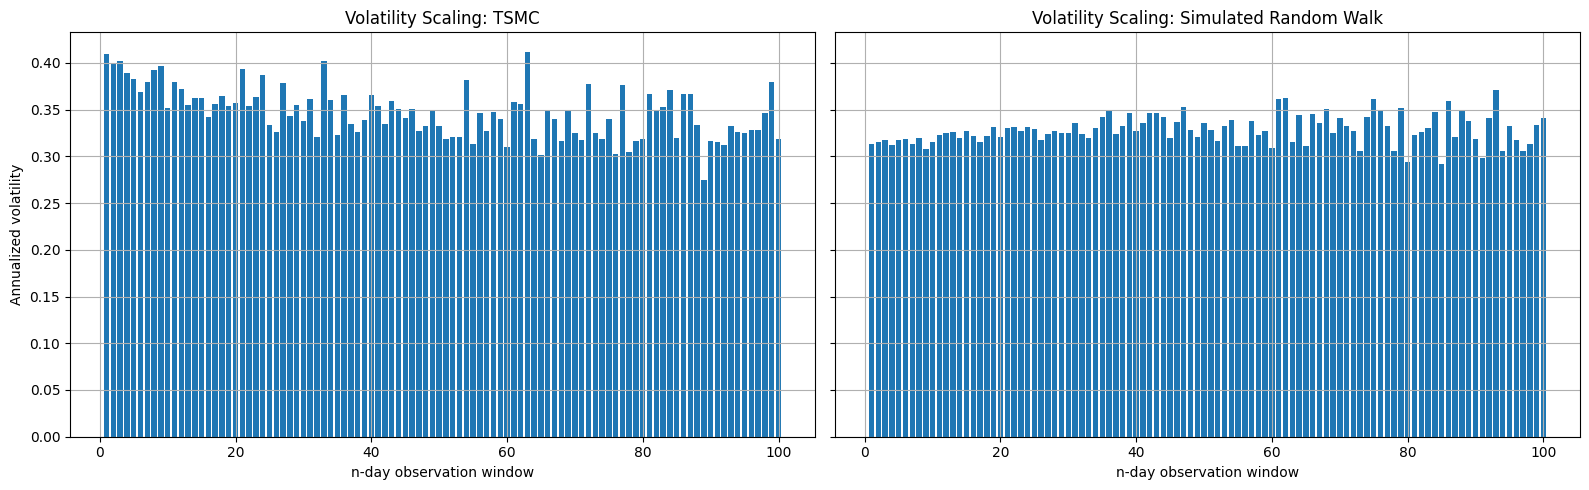

In [50]:
# lts check if volatility scales exactly like a random walk
P = tsm["Adj Close"].squeeze().dropna()
N = len(P)

sigma = []

for n in range(1, 101):
    sampled_prices = P.iloc[::n]
    sampled_returns = np.diff(np.log(sampled_prices))

    annualized_vol = np.sqrt(252 / n) * np.std(sampled_returns)
    sigma.append(annualized_vol)


np.random.seed(123)
P_MC = np.exp(np.cumsum(np.random.normal(loc=0, scale=0.02, size=N)))

sigma_MC = []

for n in range(1, 101):
    sampled_prices_MC = P_MC[::n]
    sampled_returns_MC = np.diff(np.log(sampled_prices_MC))

    annualized_vol_MC = np.sqrt(252 / n) * np.std(sampled_returns_MC)
    sigma_MC.append(annualized_vol_MC)


fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

axes[0].bar(range(1, 101), sigma)
axes[0].set_title("Volatility Scaling: TSMC")
axes[0].set_xlabel("n-day observation window")
axes[0].set_ylabel("Annualized volatility")
axes[0].grid()

axes[1].bar(range(1, 101), sigma_MC)
axes[1].set_title("Volatility Scaling: Simulated Random Walk")
axes[1].set_xlabel("n-day observation window")
axes[1].grid()

plt.tight_layout()
plt.show()

# Final insights
* We observed that TSMC returns do not behave exactly like a pure iid random walk process, the variance ratio test was rejected 

* However, this does not mean that Bachelier, Fama, Lo, or MacKinlay were “wrong”, their contributions were that financial prices may behave approximately like random walks and that market prices rapidly incorporate available information

* Our small empirical experiment suggests that the market is more complex than a pure random walk model. Prices may contain additional structure such as temporal dependence, volatility clustering, mean reversion, or market microstructure effects (politics, historical structures, etc)

* But, one of the deepest insights of the efficent market theory is that price changes should mainly reflect the arrival of new information (“news”) whichch is inherently difficult to predict. This explains why financial markets often appear noisy and highly random

**How would it be if we test the random walk hypothesis on crypto?**